# Análisis Básico de la Actividad e Inactividad EMG 
### Daniel Yedra Cázares, Erin C. McKiernan, Marco Arieli Herrera-Valdez,
### Facultad de Ciencias, UNAM


## Tabla de contenidos:
[1. Introducción](#introduction)

[1.1 Inicialización del Notebook](#IN)

[2.1. Clase EM ](#EM)

[2.2 Registro](#Re1)

[2.2.1 Resultados del método](#Re_M)

[2.2.2 Histogramas de Desviación Estándar](#Hist_DE)

[2.2.3. Valores que regresa el método](#OB_VM)

[3. Interpretación de los Resultados](#Inter_Re)


<a id='introduction'></a>
# Introducción

En este cuaderno se busca realizar un análisis básico de la actividad e inactividad en una señal de electromiografía (EMG). El objetivo principal es estudiar la variabilidad de la señal EMG en diferentes intervalos de actividad muscular y en reposo, respondiendo a preguntas clave que nos permitan entender mejor la naturaleza de estas fluctuaciones y su relación.

Las preguntas a abordar en este análisis son las siguientes:

1.	¿Cómo podemos distinguir entre actividad e inactividad muscular en una señal EMG?
Se busca establecer un método para identificar los intervalos de actividad muscular y los de inactividad, y explorar cómo estos se relacionan con los parámetros de la señal.
2.	¿Cómo se comportan las desviaciones estándar durante la actividad e inactividad? ¿Son significativamente diferentes entre estos dos estados?
Mediante el cálculo de la desviación estándar en ambos estados, se evaluará si existe una diferencia estadísticamente significativa entre las variabilidades de la señal durante la actividad muscular y durante el reposo. Esto nos ayudará a entender mejor las características de la señal EMG en diferentes condiciones.

<a id='IN'></a>
## Inicialización del Notebook

In [1]:
%matplotlib inline 

import matplotlib.pyplot as plt
import math
import numpy as np
import scipy.stats as scs 
import scipy as sc
from scipy import signal
from scipy.signal import butter, lfilter, filtfilt,iirnotch 
import wave
from ipywidgets import interact, interactive, fixed, interact_manual
import ipywidgets as widgets
import seaborn as sns
import mplcursors
from scipy.stats import gaussian_kde
from statsmodels.distributions.empirical_distribution import ECDF
from matplotlib.ticker import MaxNLocator
from scipy.ndimage import binary_closing
import pandas as pd


%config InlineBackend.figure_formats = {'png', 'retina'} 
plt.rcParams['axes.labelsize'] = 18 
plt.rcParams['axes.titlesize'] = 20 
plt.rcParams['font.size'] = 16 
plt.rcParams['lines.linewidth'] = 1.6 

<a id='EM'></a>
## Clase EM

El método principal que vamos a utilizar para el análisis es EM.analizar_actividad_rms(low_cutoff=20, high_cutoff=450, ventana_ms=50, percentil_umbral=90, duracion_minima=0.2). Este método realiza el análisis de la actividad e inactividad de la señal EMG utilizando un filtro bandpass, un cálculo de RMS móvil y un umbral basado en el percentil de la señal filtrada.

A continuación, se explican los parámetros de este método:
 
1.	low_cutoff y high_cutoff:
Estos parámetros definen el rango de frecuencias para el filtro bandpass que se aplica a la señal EMG. El low_cutoff (frecuencia de corte inferior) y el high_cutoff (frecuencia de corte superior) especifican los límites de frecuencia que se mantienen, mientras que las frecuencias fuera de este rango se atenúan. Esto ayuda a eliminar ruido de baja o alta frecuencia que no pertenece a la señal EMG de interés.
2.	ventana_ms:
Este parámetro define el tamaño de la ventana para el cálculo del RMS móvil. El valor de la ventana se da en milisegundos y determina cuántos puntos de la señal se tomarán para calcular el RMS de manera local a lo largo del tiempo. Cuanto mayor sea la ventana, más suavizado estará el cálculo del RMS.
	
3.	percentil_umbral:
Este parámetro establece el percentil de la señal RMS que se utiliza para definir el umbral de actividad. Cualquier valor de RMS mayor que el umbral se considera como actividad muscular, mientras que los valores inferiores se consideran como inactividad. 

4.	duracion_minima:
Este parámetro define la duración mínima de un intervalo de actividad o inactividad para ser considerado válido. Si un intervalo tiene una duración menor que este valor, se descartará. Este parámetro ayuda a filtrar eventos breves y no significativos que podrían ser causados por ruido o fluctuaciones transitorias de la señal.
	*	Se establece en 0.2 segundos, lo que significa que cualquier intervalo de actividad o inactividad que dure menos de 200 ms se descartará, garantizando que solo se incluyan intervalos de suficiente duración.

In [2]:
class EM:
    def __init__(self, archivo=None, señal=None, tasa_muestra=None):
        if archivo:
            # Si se pasa un archivo, cargarlo
            self.cargar_archivo(archivo)
        elif señal is not None and tasa_muestra is not None:
            # Si se pasa directamente la señal y la frecuencia de muestreo
            self.señal= señal
            self.tasa_muestra = tasa_muestra
            self.vector_tiempo = self.crear_vector_tiempo()
        else:
            raise ValueError("Debes proporcionar un archivo o la señal y frecuencia de muestreo.")
    
    def cargar_archivo(self, archivo):
        with wave.open(archivo, 'rb') as muestra:
            # Extraer el número de canales, la tasa de muestreo y los datos
            num_canales =  muestra.getnchannels()  # Número de canales
            N = muestra.getnframes()  # Número de frames
            self.tasa_muestra = muestra.getframerate()  # Tasa de muestreo

            # Extraer datos de la grabación .wav
            dstr = muestra.readframes(N * num_canales)
            self.señal = np.frombuffer(dstr, np.int16) #Lo que era waveData antes

            # Crear el vector de tiempo basado en la señal y la frecuencia de muestreo
            self.vector_tiempo = self.crear_vector_tiempo()

            # Imprimir información relevante
            print(f'El registro tiene {num_canales} canal(es).')
            print(f'La frecuencia de muestreo de la grabación es {self.tasa_muestra} Hz.')

    def crear_vector_tiempo(self):
        return np.linspace(0, len(self.señal) / self.tasa_muestra, num=len(self.señal))
    def visualizar(self,xmin,xmax):
        # Crear la figura
        fig, ax1 = plt.subplots(figsize=(12, 6))  # Tamaño más compacto y elegante
        
        # Graficar los datos
        ax1.plot(self.vector_tiempo, self.señal, color='dodgerblue', linewidth=1.5, label='Señal EM')

        # Añadir título y etiquetas
        ax1.set_title('Datos del Registro', fontsize=22, fontweight='bold', color='darkblue')  # Título en negrita y azul
        ax1.set_xlabel('Tiempo (s)', fontsize=16, color='darkgreen')  # Eje X con color
        ax1.set_ylabel('Voltaje ($\mu$V)', fontsize=16, color='darkgreen')  # Eje Y con color

        # Ajustar los límites según xmin y xmax
        ax1.set_xlim(xmin, xmax)
        ax1.set_ylim(-max(self.señal), max(self.señal))

        # Mejorar la estética de los ejes
        ax1.tick_params(axis='both', labelsize=12, colors='black')  # Mejorar tamaño y color de los ticks

        # Agregar una cuadrícula (grid) con un estilo suave
        ax1.grid(True, linestyle='--', alpha=0.7, color='gray')

        # Mostrar leyenda con los límites del eje x
        ax1.legend(loc='upper right', fontsize=14, title=f"xlim: ({xmin}, {xmax})")

        # Mostrar la gráfica
        plt.tight_layout()  # Ajustar el diseño automáticamente para que no se corten los elementos
        plt.show()
        
    def Señal_filtrada_Bandpass(self,low_cutoff,high_cutoff):

        b, a = butter(2, [low_cutoff / (self.tasa_muestra / 2), high_cutoff / (self.tasa_muestra / 2)], btype='bandpass')
        Señal_bandpass = filtfilt(b, a, self.señal)
    
        return Señal_bandpass
        
    def visualizar_filtrada(self, xmin, xmax, low_cutoff, high_cutoff):
        # Obtener la señal filtrada
        señal_filtrada = self.Señal_filtrada_Bandpass(low_cutoff, high_cutoff)
        
        # Crear la figura
        fig, ax1 = plt.subplots(figsize=(12, 6))
        
        # Graficar la señal cruda (con opacidad reducida) y la señal filtrada
        ax1.plot(self.vector_tiempo, self.señal, color='dodgerblue', linewidth=1.5, label='Señal EM Cruda', alpha=0.5)
        ax1.plot(self.vector_tiempo, señal_filtrada, color='darkred', linewidth=2, label='Señal EM Filtrada')
        
        # Añadir título y etiquetas
        ax1.set_title('Datos Crudos vs. Filtrado usando BP', fontsize=22, fontweight='bold', color='darkblue')
        ax1.set_xlabel('Tiempo (s)', fontsize=16, color='darkgreen')
        ax1.set_ylabel('Voltaje ($\mu$V)', fontsize=16, color='darkgreen')

        # Ajustar los límites del eje x según xmin y xmax
        ax1.set_xlim(xmin, xmax)
        ax1.set_ylim(-max(self.señal), max(self.señal))

        # Mejorar la estética de los ejes
        ax1.tick_params(axis='both', labelsize=12, colors='black')
        ax1.grid(True, linestyle='--', alpha=0.7, color='gray')
        ax1.legend(loc='upper right', fontsize=14, title=f"xlim: ({xmin}, {xmax})")

        plt.tight_layout()
        plt.show()
        
    def aproxDer(self): 
        V = np.array(self.señal)  # Convertimos los datos a un array de NumPy
        N = len(V)
        DT=1/self.tasa_muestra
    
        if N < 2:
            return np.zeros(N)  # Si hay menos de 2 elementos, no se puede derivar
    
        derivadas = np.zeros(N)  # Inicializamos un array del mismo tamaño
    
        if N > 2:
            # Derivada central para los puntos intermedios
            derivadas[1:-1] = (V[2:] - V[:-2]) / (2 * DT)
    
        # Derivada hacia adelante en el primer punto
        derivadas[0] = (V[1] - V[0]) / DT
    
        # Derivada hacia atrás en el último punto
        derivadas[-1] = (V[-1] - V[-2]) / DT

        return derivadas
        
    def aprox_2Der(self):

        V = np.array(self.señal)  # Convertir a array de NumPy
        N = len(V)
        DT=1/self.tasa_muestra
    
        if N < 3:
            return np.zeros(N)  # No es posible calcular la segunda derivada con menos de 3 puntos
    
        derivadas2 = np.zeros(N)
    
        # Derivada central para puntos intermedios:
        # f''(x) ≈ (f(x+DT) - 2 f(x) + f(x-DT)) / DT²
        derivadas2[1:-1] = (V[2:] - 2 * V[1:-1] + V[:-2]) / (DT ** 2)
    
        # Para el primer y último punto usamos aproximaciones hacia adelante y hacia atrás:
        derivadas2[0] = (V[2] - 2 * V[1] + V[0]) / (DT ** 2)
        derivadas2[-1] = (V[-1] - 2 * V[-2] + V[-3]) / (DT ** 2)
    
        return derivadas2
    
    def visualizar_histograma(self, bins=50, color='skyblue', alpha=0.7, mostrar_kde=False):

        plt.figure(figsize=(10, 6))

        # Graficar el histograma con la opción de mostrar o no la KDE
        sns.histplot(self.señal, bins=bins, color=color, alpha=alpha, kde=mostrar_kde)

        plt.title('Histograma de la Señal', fontsize=22)
        plt.xlabel('Voltaje ($\mu$V)', fontsize=16)
        plt.ylabel('Frecuencia', fontsize=16)
        plt.grid(True, linestyle='--', alpha=0.7, color='gray')

        plt.tight_layout()
        plt.show()
        
    def Descrip_est(self):
        # Usar scipy.stats.describe para obtener el resumen estadístico de la señal
        stats = scs.describe(self.señal)
        
        # Desglosar los valores obtenidos
        nobs = stats.nobs          # Número de observaciones
        minmax = stats.minmax      # Mínimo y máximo de la señal
        mean = float(stats.mean)   # Convertir a tipo float
        variance = float(stats.variance)  # Convertir a tipo float
        skewness = float(stats.skewness)  # Convertir a tipo float
        kurtosis = float(stats.kurtosis)  # Convertir a tipo float
        
        # Mostrar los resultados de manera limpia
        print(f"Resumen Estadístico de la Señal EM:")
        print(f"  - Número de observaciones: {nobs}")
        print(f"  - Mínimo y máximo: {minmax}")
        print(f"  - Media: {mean:.4f}")  # Mostrar con 4 decimales
        print(f"  - Varianza: {variance:.4f}")  # Mostrar con 4 decimales
        print(f"  - Asimetría: {skewness:.4f}")  # Mostrar con 4 decimales
        print(f"  - Curtosis: {kurtosis:.4f}")  # Mostrar con 4 decimales

    # Método para discriminar por amplitud
    def discriminar_por_amplitud(self, umbral=400):
        # Crear un DataFrame con la señal y su tiempo
        df = pd.DataFrame({'Tiempo': self.vector_tiempo, 'Amplitud': self.señal})
        
        # Filtrar el DataFrame por amplitudes mayores al umbral
        filtered = df[df["Amplitud"] > umbral]
        
        # Mostrar la gráfica de las amplitudes mayores al umbral
        plt.figure(figsize=(12, 6))
        plt.plot(filtered['Tiempo'], filtered['Amplitud'], color='dodgerblue', linewidth=1.5)
        plt.title(f'Señal Filtrada por Amplitud > {umbral} $\mu$V', fontsize=22, fontweight='bold', color='darkblue')
        plt.xlabel('Tiempo (s)', fontsize=16, color='darkgreen')
        plt.ylabel('Amplitud ($\mu$V)', fontsize=16, color='darkgreen')
        plt.grid(True, linestyle='--', alpha=0.7, color='gray')
        plt.tight_layout()
        plt.show()
        
        return filtered  # Devuelve el DataFrame filtrado

    # Método para dividir la señal en ventanas de tiempo
    def ventana_1_canal(self, x, npoints):
        single_chan_wind = []
        tot_points = len(x)  # Número total de puntos en la serie
        L = npoints

        nwind = tot_points // npoints  # Número de ventanas

        for h in range(0, nwind):
            t = x[h * L:L * (1 + h)]  # Separar en ventanas
            single_chan_wind.append(t)  # Guardar las ventanas

        return single_chan_wind

    # Método para calcular la varianza en cada ventana de tiempo
    def varianza_ventana_1_canal(self, x, npoints):
        tot_points = len(x)  # Número total de puntos
        nwind = tot_points // npoints  # Número de ventanas
        wind_x = self.ventana_1_canal(x, npoints)  # Llamada a la función para obtener las ventanas
        
        # Calcular la varianza de cada ventana
        v_single_chan_wind = [np.var(wind_x[w]) for w in range(0, nwind)]
        
        return v_single_chan_wind

    # Método para visualizar la varianza de la señal en ventanas de tiempo
    def visualizar_varianza(self, npoints=50000):
        # Normalizar la varianza para una mejor visualización
        varianza = self.varianza_ventana_1_canal(self.señal, npoints)
        varianza_normalizada = np.array(varianza) / max(varianza)

        # Crear la figura
        plt.figure(figsize=(20, 5), dpi=100)
        plt.title('Varianza del EM en ventanas de tiempo')
        plt.xlabel('Ventana de tiempo')
        plt.ylabel('Varianza')

        # Graficar la varianza normalizada
        plt.plot(varianza_normalizada)
        plt.grid(True, linestyle='--', alpha=0.7, color='gray')
        plt.tight_layout()
        plt.show()

    #Método de Actividad e Inactividad

    def analizar_actividad_rms(self, low_cutoff=20, high_cutoff=450, ventana_ms=50, percentil_umbral=90, duracion_minima=0.2):

        # 1. Filtrado bandpass
        señal_filtrada = self.Señal_filtrada_Bandpass(low_cutoff, high_cutoff)
        fs = self.tasa_muestra
        time_vector = self.vector_tiempo

        # 2. Calcular RMS móvil
        window_size = int((ventana_ms / 1000) * fs)
        squared = np.power(señal_filtrada, 2)
        window = np.ones(window_size) / window_size
        rms = np.sqrt(np.maximum(np.convolve(squared, window, mode='same'), 0))

        # 3. Calcular umbral
        threshold = np.percentile(rms, percentil_umbral)
        actividad_binaria = rms > threshold

        # 4. Suavizar actividad usando cierre morfológico
        estructura = np.ones(int(0.1 * fs))  # estructura de 100 ms
        actividad_binaria_suavizada = binary_closing(actividad_binaria, structure=estructura)

        # 5. Detectar intervalos de actividad e inactividad
        def get_intervals(binary_array, time_vector):
            intervals = []
            current_state = binary_array[0]
            start_time = time_vector[0]
            for i in range(1, len(binary_array)):
                if binary_array[i] != current_state:
                    end_time = time_vector[i-1]
                    intervals.append((start_time, end_time, current_state))
                    current_state = binary_array[i]
                    start_time = time_vector[i]
            intervals.append((start_time, time_vector[-1], current_state))
            return intervals

        intervals = get_intervals(actividad_binaria_suavizada, time_vector)
        intervals_filtrados = [(s, e, st) for (s, e, st) in intervals if (e - s) >= duracion_minima]

        actividad_intervals = [(s, e) for (s, e, st) in intervals_filtrados if st]
        inactividad_intervals = [(s, e) for (s, e, st) in intervals_filtrados if not st]

        # 6. Calcular estadísticas por intervalo
        def calcular_rms(segmento):
            return np.sqrt(np.mean(np.power(segmento, 2)))

        def calcular_std(segmento):
            return np.std(segmento)

        rms_act = []
        std_act = []
        for (s, e) in actividad_intervals:
            seg = señal_filtrada[(time_vector >= s) & (time_vector <= e)]
            if len(seg) > 0:
                rms_act.append(calcular_rms(seg))
                std_act.append(calcular_std(seg))

        rms_inact = []
        std_inact = []
        for (s, e) in inactividad_intervals:
            seg = señal_filtrada[(time_vector >= s) & (time_vector <= e)]
            if len(seg) > 0:
                rms_inact.append(calcular_rms(seg))
                std_inact.append(calcular_std(seg))

        mean_rms_actividad = np.mean(rms_act) if rms_act else None
        mean_rms_inactividad = np.mean(rms_inact) if rms_inact else None
        snr = mean_rms_actividad / mean_rms_inactividad if mean_rms_inactividad else None

        # Realizar un t-test para comparar medias
        t_stat, p_value = scs.ttest_ind(std_act, std_inact)

        # 7. Visualización sin huecos
        plt.figure(figsize=(12, 6))
        plt.plot(time_vector, señal_filtrada, label='Señal EMG Filtrada', alpha=0.5)
        plt.plot(time_vector, rms, label='RMS móvil', linewidth=2)
        plt.axhline(y=threshold, color='r', linestyle='--', label='Umbral')

        etiquetas_mostradas = {"Actividad": False, "Inactividad": False}
        for (s, e, st) in intervals_filtrados:
            if st:
                plt.axvspan(s, e, color='orange', alpha=0.2,
                            label='Actividad' if not etiquetas_mostradas["Actividad"] else "")
                etiquetas_mostradas["Actividad"] = True
            else:
                plt.axvspan(s, e, color='green', alpha=0.2,
                            label='Inactividad' if not etiquetas_mostradas["Inactividad"] else "")
                etiquetas_mostradas["Inactividad"] = True

        plt.xlabel('Tiempo (s)', fontsize=14)
        plt.ylabel('Amplitud / RMS', fontsize=14)
        plt.title('Segmentación de Actividad e Inactividad en la Señal EMG', fontsize=16)
        plt.legend(loc='upper right')
        plt.grid(True, linestyle='--', alpha=0.7)
        plt.tight_layout()
        plt.show()

        # 8. Histogramas de desviación estándar
        plt.style.use("seaborn-v0_8-darkgrid")
        fig, axs = plt.subplots(1, 2, figsize=(14, 6))

        counts_act, bins_act, patches_act = axs[0].hist(std_act, bins=10, color='#4C72B0', edgecolor='black', alpha=0.7)
        axs[0].xaxis.set_major_locator(MaxNLocator(nbins=6))
        axs[0].set_xlabel('Desviación Estándar (Actividad)', fontsize=12, fontweight='bold', color='darkblue')
        axs[0].set_ylabel('Frecuencia', fontsize=12, fontweight='bold', color='darkred')
        axs[0].set_title('Histograma de Desviación Estándar en Actividad', fontsize=14, fontweight='bold', color='purple')
        axs[0].grid(axis='y', linestyle='--', alpha=0.7)
        sns.despine(ax=axs[0], left=True, bottom=True)

        cmap = plt.get_cmap("coolwarm")
        for i, patch in enumerate(patches_act):
            patch.set_facecolor(cmap(i / len(patches_act)))

        counts_inact, bins_inact, patches_inact = axs[1].hist(std_inact, bins=10, color='#C44E52', edgecolor='black', alpha=0.7)
        axs[1].xaxis.set_major_locator(MaxNLocator(nbins=6))
        axs[1].set_xlabel('Desviación Estándar (Inactividad)', fontsize=12, fontweight='bold', color='darkblue')
        axs[1].set_ylabel('Frecuencia', fontsize=12, fontweight='bold', color='darkred')
        axs[1].set_title('Histograma de Desviación Estándar en Inactividad', fontsize=14, fontweight='bold', color='purple')
        axs[1].grid(axis='y', linestyle='--', alpha=0.7)
        sns.despine(ax=axs[1], left=True, bottom=True)

        for i, patch in enumerate(patches_inact):
            patch.set_facecolor(cmap(i / len(patches_inact)))

        plt.tight_layout()
        plt.show()

        # Resultados
        print("RMS promedio en inactividad:", mean_rms_inactividad)
        print("RMS promedio en actividad:", mean_rms_actividad)
        print("\nRelación Señal/Ruido (SNR):", snr)

        return {
            "actividad_intervals": actividad_intervals,
            "inactividad_intervals": inactividad_intervals,
            "mean_rms_actividad": mean_rms_actividad,
            "mean_rms_inactividad": mean_rms_inactividad,
            "snr": snr,
            "std_actividad": std_act,
            "std_inactividad": std_inact,
            "Estadistico T": t_stat,
            "P-value":p_value
            
        }


<a id='Re1'></a>
## Registro

Para este análisis, se utilizó un registro realizado bajo el siguiente protocolo:

1.	Colocación de Electrodos:
Los electrodos se colocaron en la mano no dominante de la siguiente manera:
	*	Electrodos de actividad:
Uno de los electrodos se colocó sobre el músculo oponente del pulgar y el otro sobre el extensor de los dedos. Esta disposición  se penso para registrar la actividad eléctrica generada por la contracción de los músculos involucrados en el movimiento del pulgar.


	*	Electrodo de tierra: El electrodo de tierra se colocó en una zona neutral del cuerpo, es decir, en un área que no estuviera  influenciada por la actividad de los músculos, para proporcionar una referencia estable y minimizar el ruido durante la grabación.

3.	Proceso de Grabación:
La señal fue registrada utilizando el software SpikeRecorder. Durante el registro, el antebrazo del brazo en cuestión se apoyó sobre una almohada, mientras que la muñeca se mantenía ligeramente sobrevolada para asegurar una postura cómoda y estable durante la medición.


4. Movimientos del Pulgar:
Se dejó un breve periodo de reposo antes de iniciar el movimiento del pulgar. Con la palma hacia abajo, se procedió a mover el pulgar de arriba hacia abajo durante un intervalo de 50 segundos. Al finalizar este periodo, se dejó un intervalo de 10 segundos de reposo antes de concluir el registro.

In [3]:
EMG = EM(archivo="/Users/danielyedra/Music/Spike Recorder/Registro3_Pulgar.wav")

# Acceder a los atributos del objeto
print(f"Señal de la muestra: {EMG.señal}")
print(f"Tiempo de la señal: {EMG.vector_tiempo[-1]} segundos")

#Método que nos da una descripción estadistica simple
EMG.Descrip_est()

El registro tiene 1 canal(es).
La frecuencia de muestreo de la grabación es 44100 Hz.
Señal de la muestra: [-283 -302 -336 ...  392  395  405]
Tiempo de la señal: 60.434988662131516 segundos
Resumen Estadístico de la Señal EM:
  - Número de observaciones: 2665183
  - Mínimo y máximo: (np.int16(-32765), np.int16(32767))
  - Media: 59.5497
  - Varianza: 22018504.5259
  - Asimetría: -0.2346
  - Curtosis: 13.4379


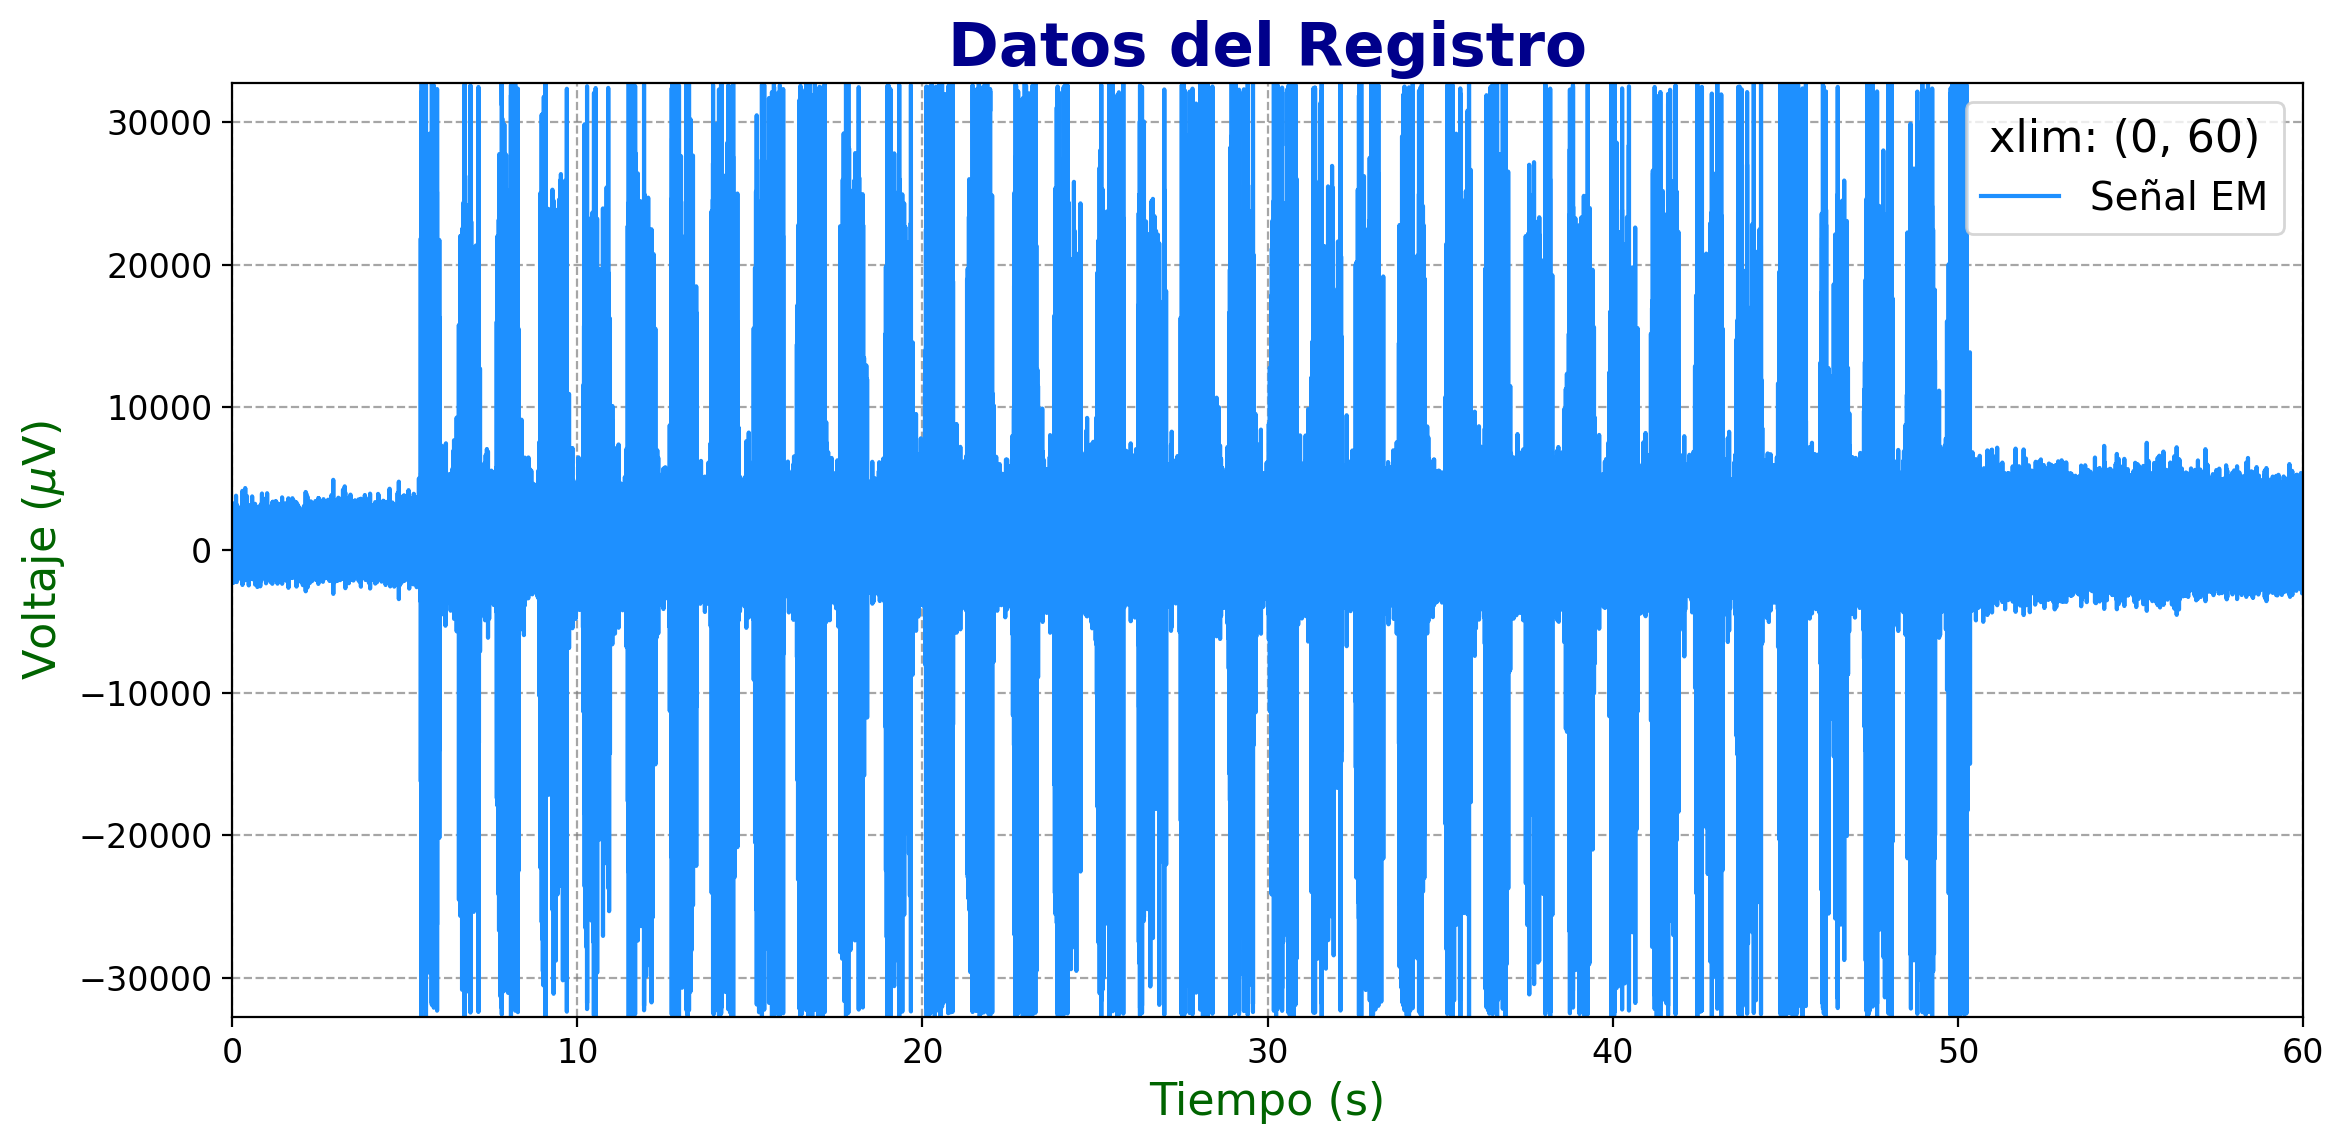

In [4]:
EMG.visualizar(0,60)

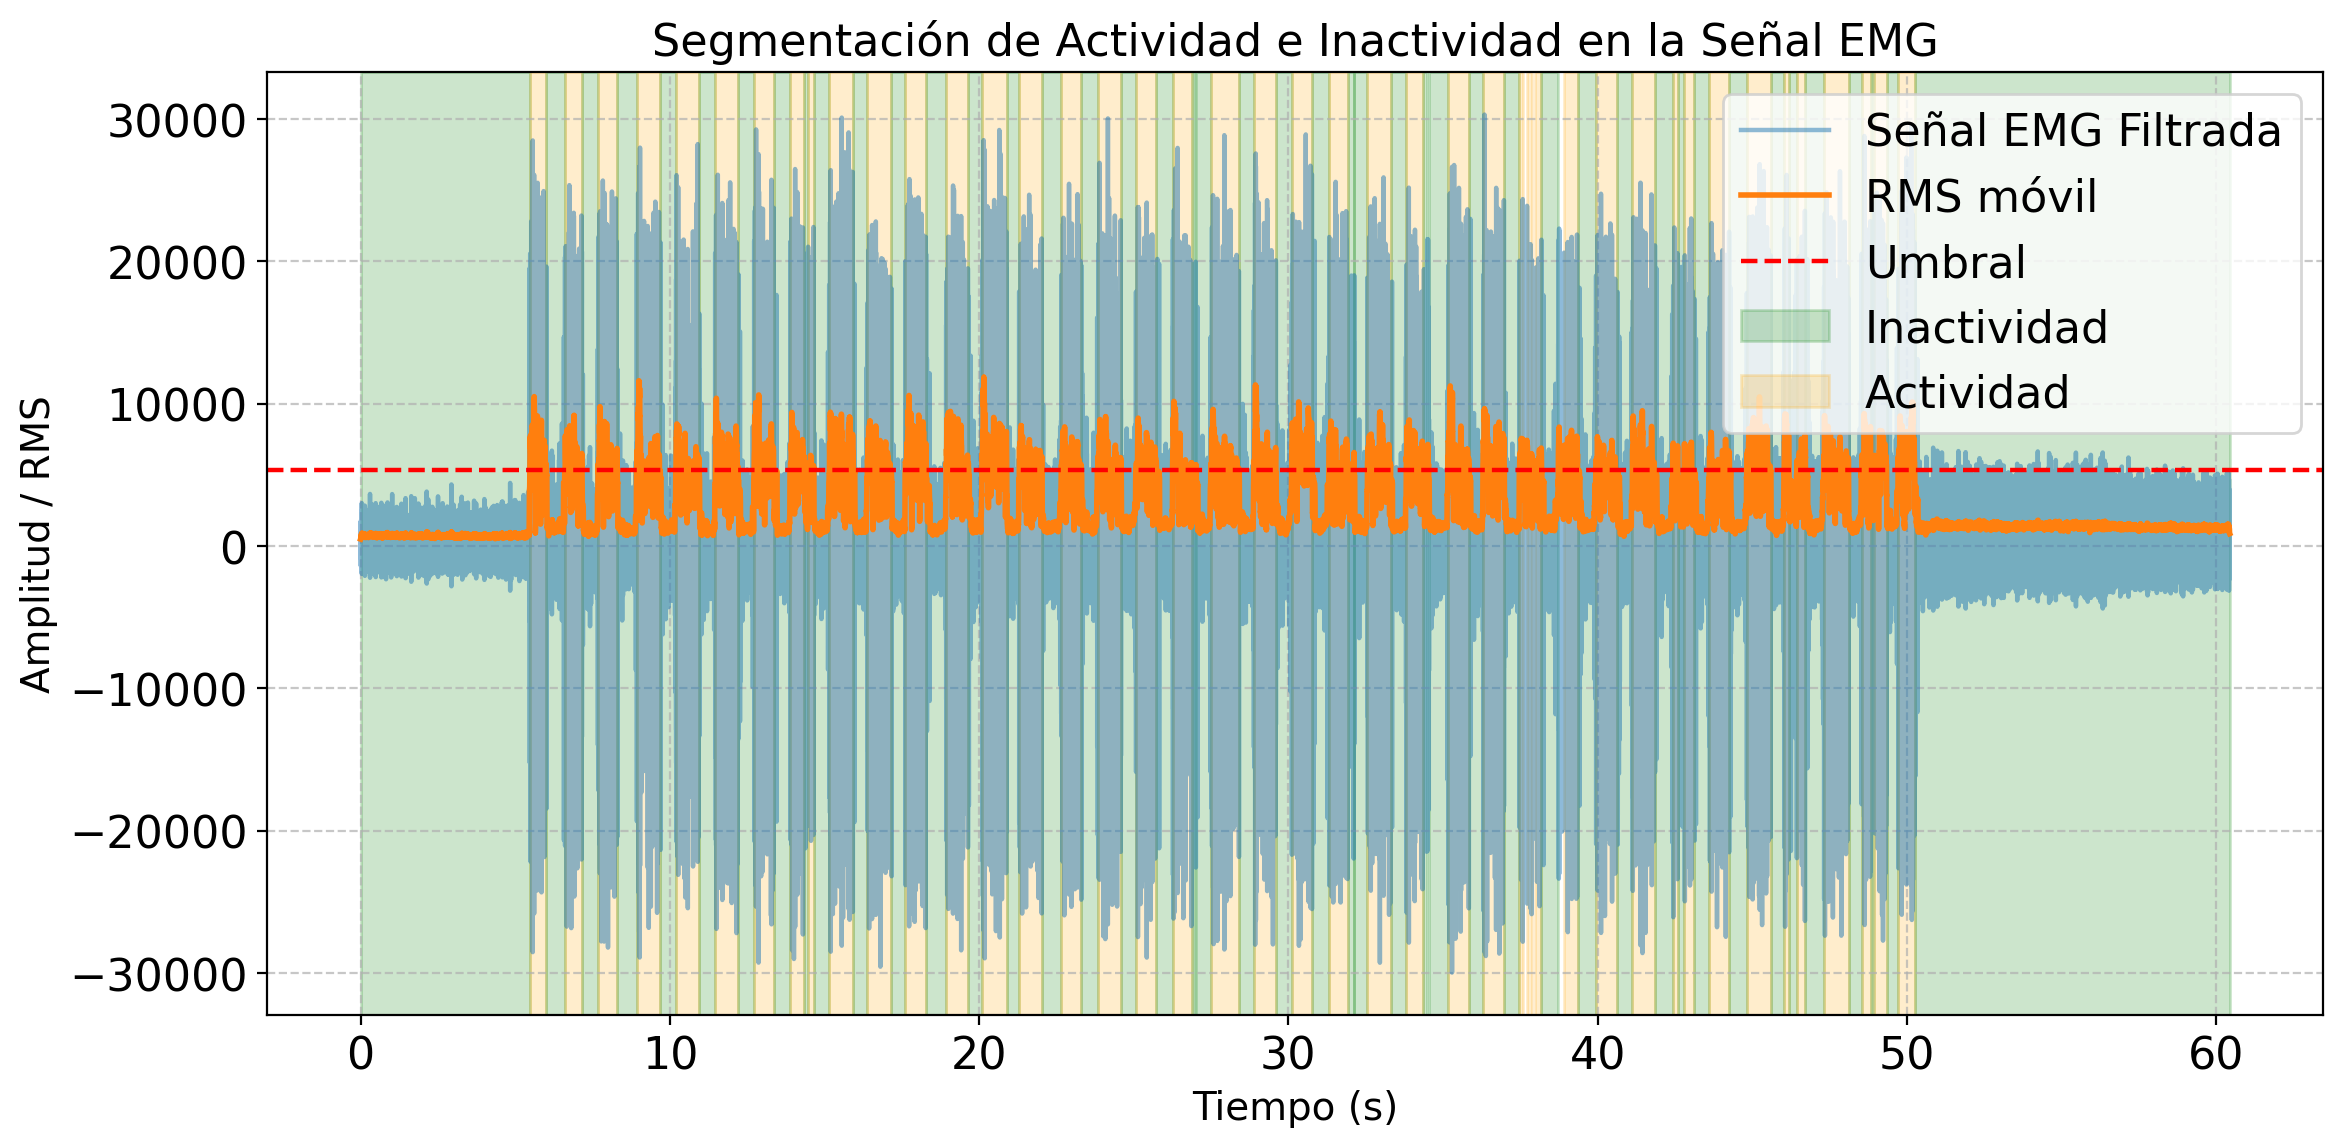

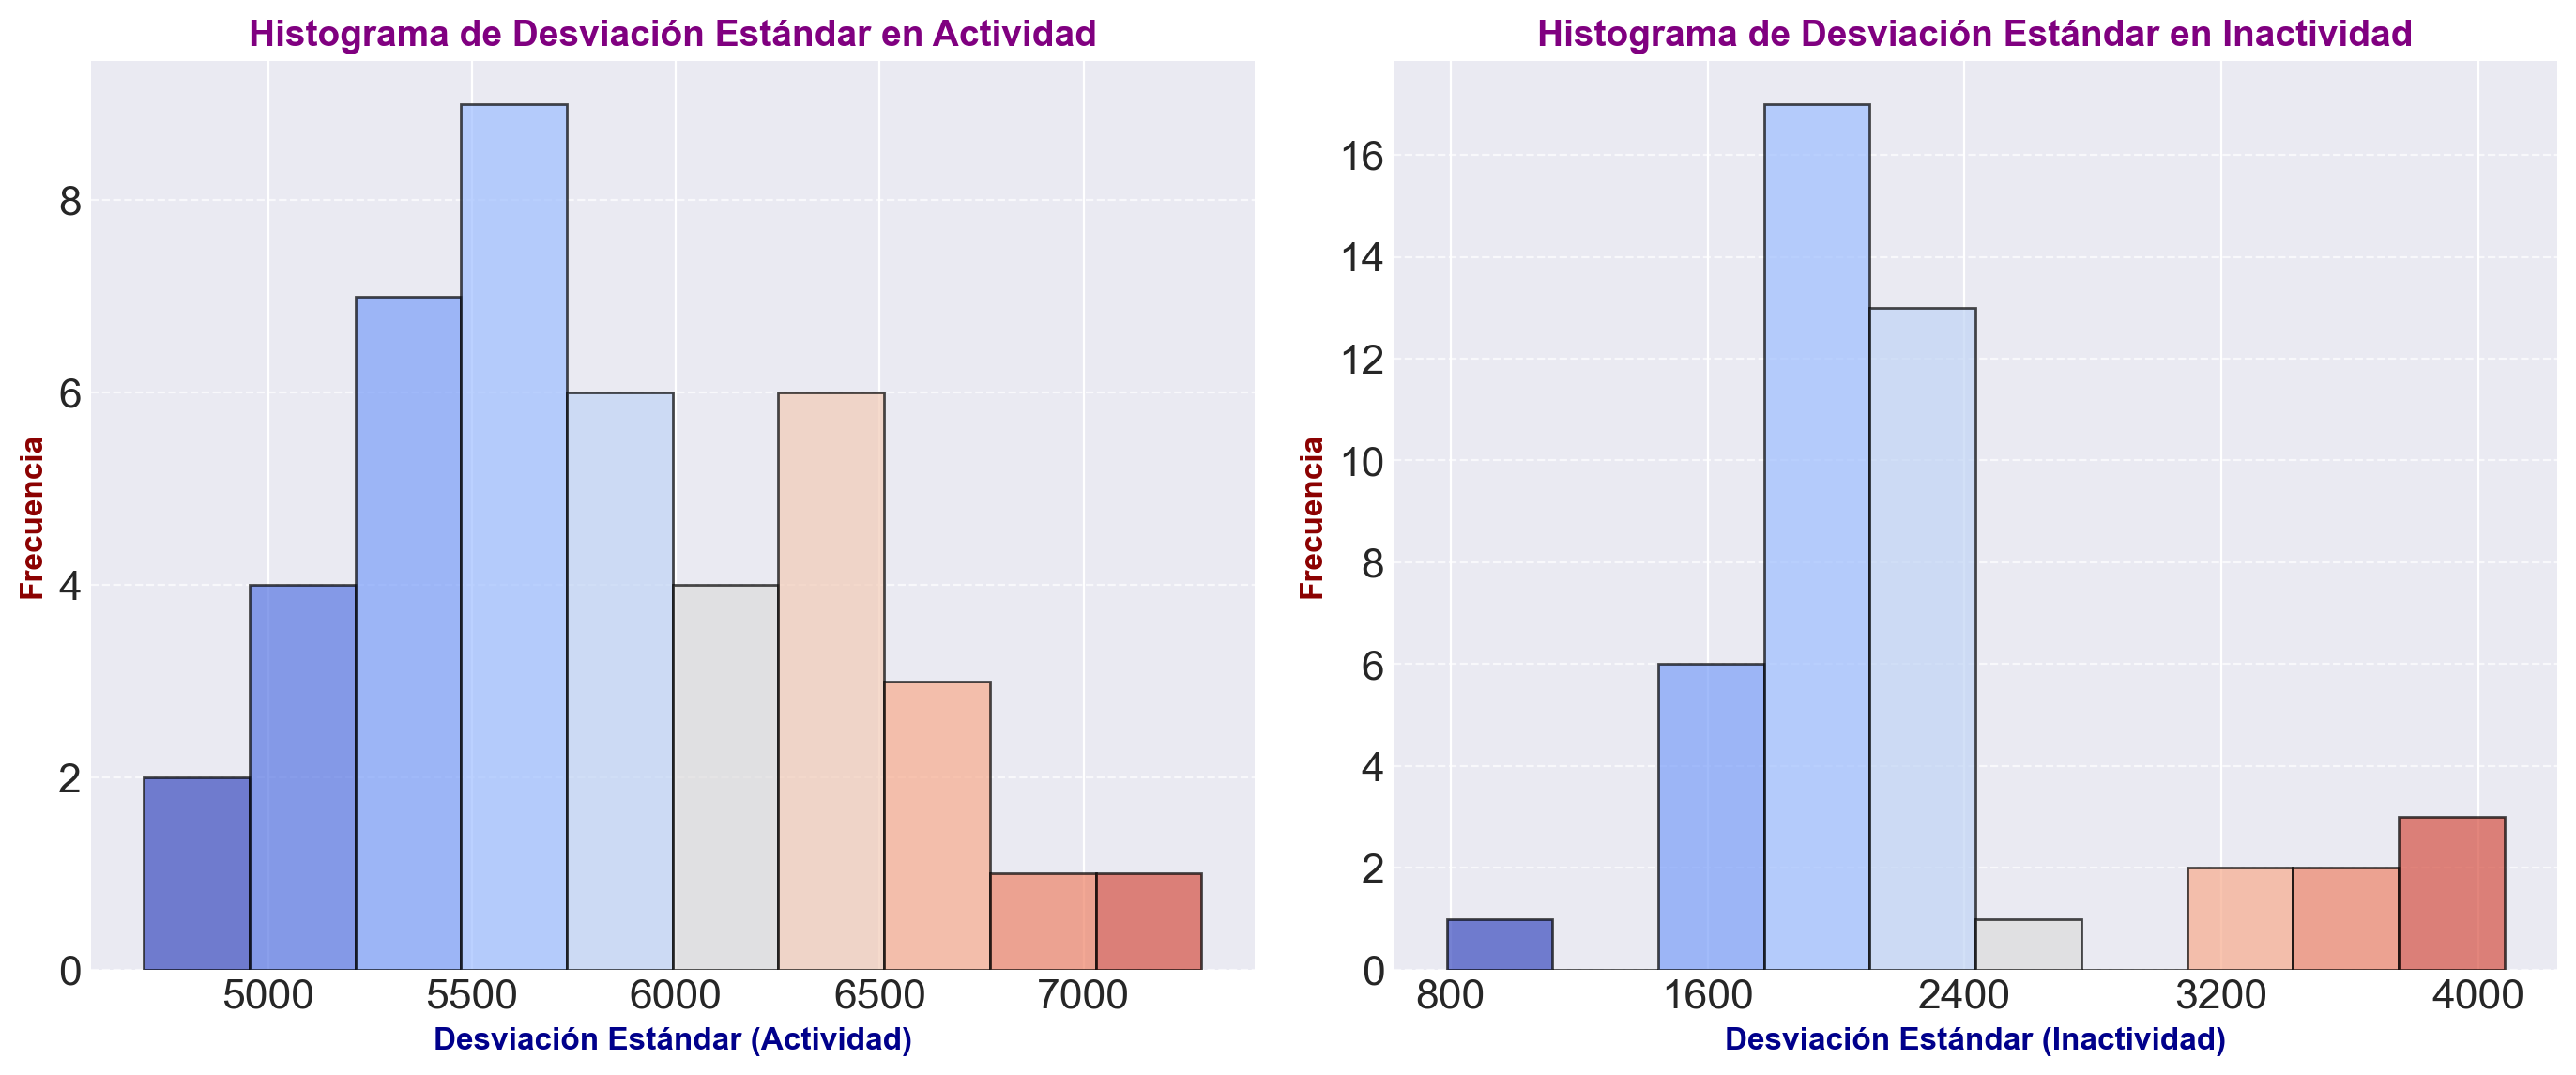

RMS promedio en inactividad: 2251.6833289289634
RMS promedio en actividad: 5829.181422210522

Relación Señal/Ruido (SNR): 2.5888104900537825


In [5]:
A=EMG.analizar_actividad_rms(low_cutoff=100, high_cutoff=1000, ventana_ms=30, percentil_umbral=75,duracion_minima=0.11)

<a id='Re_M'></a>
## Resultados del método

A partir del método realizado con el registro, los resultados obtenidos son los siguientes:

1.	Intervalos de Inactividad:
Se identificaron los periodos de reposo o inactividad, los cuales se definen como aquellos en los que la envolvente RMS de la señal está por debajo del umbral previamente definido. Estos intervalos indican que el músculo no está realizando contracciones significativas durante esos momentos.

2.	RMS en Inactividad para Cada Intervalo:
Se calculó el RMS de la señal durante cada intervalo de inactividad. Cada valor refleja la amplitud promedio de la señal en términos de RMS durante el periodo de reposo. Esto permite tener una idea de la actividad residual o el nivel de ruido durante el reposo.


3.	RMS Promedio en Inactividad:
Se obtuvo el RMS promedio en los periodos de inactividad, lo que proporciona una medida general de la actividad de fondo o ruido en la señal cuando el músculo no está activamente contrayéndose.


4.	Intervalos de Actividad:
Los periodos de actividad muscular fueron identificados como aquellos en los que el RMS supera el umbral, sugiriendo que el músculo está realizando movimientos significativos, como en el caso de los toques del pulgar. Estos intervalos representan los momentos en los que hay contracción muscular.


5.	RMS en Actividad para Cada Intervalo:
Se calculó el RMS de la señal durante cada intervalo de actividad. Cada valor representa la amplitud promedio de la señal durante un toque o contracción, proporcionando información sobre la intensidad de la actividad muscular.


6.	RMS Promedio en Actividad:
Se obtuvo el RMS promedio durante los periodos de actividad, lo que refleja la magnitud promedio de la señal durante los movimientos activos del pulgar, proporcionando una medida representativa de la intensidad de la contracción muscular.


7.	Relación Señal/Ruido (SNR):
Se calculó la relación señal/ruido como la razón entre el RMS durante la actividad y el RMS durante la inactividad. Este valor indica la claridad de la señal en términos de la diferencia entre la actividad muscular y el ruido de fondo.


<a id='Hist_DE'></a>
## Histogramas de Desviación Estándar (DE)

En los histogramas de la Desviación Estándar (DE) obtenidos para la actividad e inactividad, se observan los siguientes comportamientos esperados:
	•	Actividad: La mayoría de los valores de la DE se encuentran entre 5000 y 8000, lo cual es consistente con lo esperado para contracciones musculares. Estos valores reflejan una mayor variabilidad en la señal durante la actividad muscular, probablemente debido a las contracciones musculares dinámicas.
	•	Inactividad: Los valores de la DE en los intervalos de inactividad son generalmente menores a 5000, lo que indica que, durante los periodos de reposo, la señal tiene una menor variabilidad, probablemente asociada a una baja actividad muscular o al ruido de fondo.

Este comportamiento en la desviación estándar nos permite responder a una de las preguntas clave del cuaderno, relacionada con las diferencias en la variabilidad de la señal entre la actividad y la inactividad muscular.

<a id='OB_VM'></a>
## Obtención de los valores que regresa el método

In [6]:
#Resultados del método
actividad_intervals = A["actividad_intervals"]
inactividad_intervals = A["inactividad_intervals"]
mean_rms_actividad = A["mean_rms_actividad"]
mean_rms_inactividad = A["mean_rms_inactividad"]
snr = A["snr"]
std_actividad = A["std_actividad"]
std_inactividad = A["std_inactividad"]
T_stat = A["Estadistico T"]
P_value=A["P-value"]

# Imprimir los resultados, exepto los intervalos y sus Desviaciónes estandar ya que van a ocupar bastante espacio, pero ya estan listos para usarse
print("RMS promedio de actividad:", mean_rms_actividad)
print("RMS promedio de inactividad:", mean_rms_inactividad)
print("Relación Señal/Ruido (SNR):", snr)
print("Estadistico T:",T_stat)
print("P_value:",P_value)

RMS promedio de actividad: 5829.181422210522
RMS promedio de inactividad: 2251.6833289289634
Relación Señal/Ruido (SNR): 2.5888104900537825
Estadistico T: 26.08773294419289
P_value: 1.2774862725547862e-42


<a id='Inter_Re'></a>
## Interpretación de los Resultados

Una vez aplicado el método, obtenemos un conjunto de resultados que requieren un análisis más profundo. A continuación, se detallan los aspectos más relevantes:

1.	Clasificación de Actividad e Inactividad:
Para responder a la primera pregunta planteada, es necesario entender cómo el método clasifica la actividad y la inactividad. A simple vista, esto podría parecer sencillo, ya que se trata de identificar los picos en la señal. Sin embargo, la clasificación se realiza de la siguiente manera:


	*	Una vez filtrada la señal, se calcula el RMS móvil para medir la intensidad de la señal a lo largo del tiempo. Posteriormente, se establece un umbral basado en el percentil del RMS, lo que permite clasificar la señal entre actividad e inactividad. En la gráfica siguiente se puede observar el RMS móvil junto con el umbral utilizado para la clasificación:
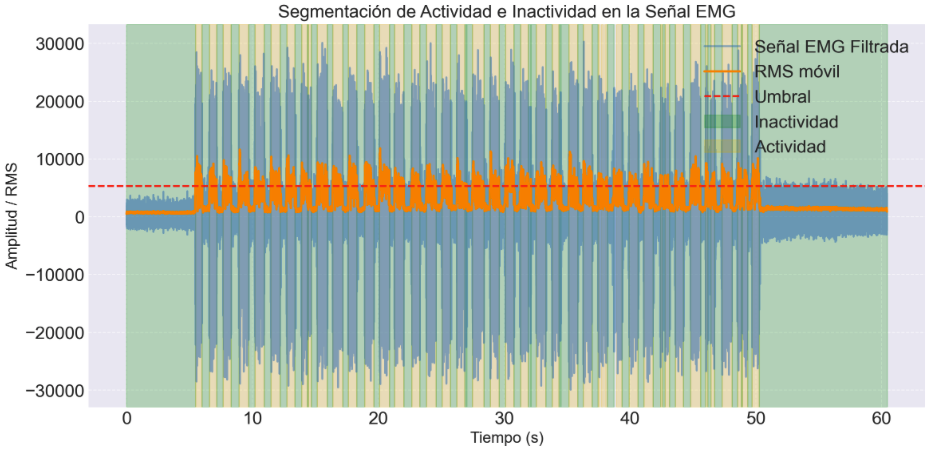
  
  
2.	Análisis de la Desviación Estándar (DE):
Como se mencionó previamente, los histogramas de la desviación estándar (DE) muestran el comportamiento esperado. Sin embargo, es crucial determinar si las desviaciones estándar entre los intervalos de actividad e inactividad son significativamente diferentes. Para ello, en el método se aplica una prueba estadística t-test que nos permite confirmar esta diferencia.
Al observar los resultados, se obtiene un valor alto en la prueba estadística, lo cual indica una diferencia considerable entre las medias de las desviaciones estándar. Además, el valor p obtenido sugiere que la diferencia entre las dos muestras es estadísticamente significativa.


	*	Conclusión: La diferencia en la desviación estándar entre los intervalos de actividad e inactividad es altamente significativa, lo que confirma que los cambios en la intensidad de la señal durante estos periodos son notoriamente distintos.

  
3.	Relación Señal/Ruido (SNR):
La SNR obtenida es baja, lo que sugiere que el ruido presente en la señal está relativamente cerca de la potencia de la señal útil. En otras palabras, la magnitud del ruido es comparable con la de la señal útil, lo cual no es ideal, ya que dificulta la interpretación precisa de la señal. Este resultado podría estar relacionado con varios factores, tales como:


	*	Posicionamiento inadecuado de los electrodos de actividad, lo que podría generar interferencias.

  
	*	Actividad detectada en el electrodo de tierra, lo que puede contribuir al ruido de la señal.

  
	*	Intensidad insuficiente del movimiento del pulgar, lo que podría haber generado señales más débiles y más susceptibles a interferencias.
Este bajo valor de SNR indica que se podrían optimizar tanto el posicionamiento de los electrodos como la intensidad del movimiento para mejorar la calidad de la señal registrada.
